# 65 - Writing a Custom `Dataset`

**Section:** Convolution and transformations | **Prereqs:** `Convolution and transformations/Image_transformations.ipynb` | **Next:** `CNNs/CNN_MNIST.ipynb`

`TensorDataset` only pairs tensors you already have in memory. Any real project -
images on disk, a CSV too big for RAM, augmentation applied per sample - needs
your own `Dataset`.

**The whole interface is three methods:**

```python
class MyDataset(Dataset):
    def __init__(self, ...):      # store paths/tensors, not the data itself
    def __len__(self):            # how many samples
    def __getitem__(self, i):     # return sample i as (x, y)
```

That is all `DataLoader` requires. Everything else - batching, shuffling, worker
processes, collation - comes free.

**Why augmentation belongs in `__getitem__`.** It runs each time a sample is
*read*, so the same image is transformed differently in every epoch. Transforming
the whole dataset once up front would give you one fixed extra copy instead of
endless variation - the difference between real augmentation and just a bigger
static dataset.

**Augmentations must preserve the label.** A small rotation leaves a digit
readable as the same digit; a vertical flip does not, and would teach the model
that upside-down sixes are sixes.

**For large data, load lazily.** Store file paths in `__init__` and read the file
in `__getitem__`. The dataset then costs nothing in memory, and with
`num_workers>0` the reads happen in parallel with GPU compute.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset


import torchvision
import torchvision.transforms as T


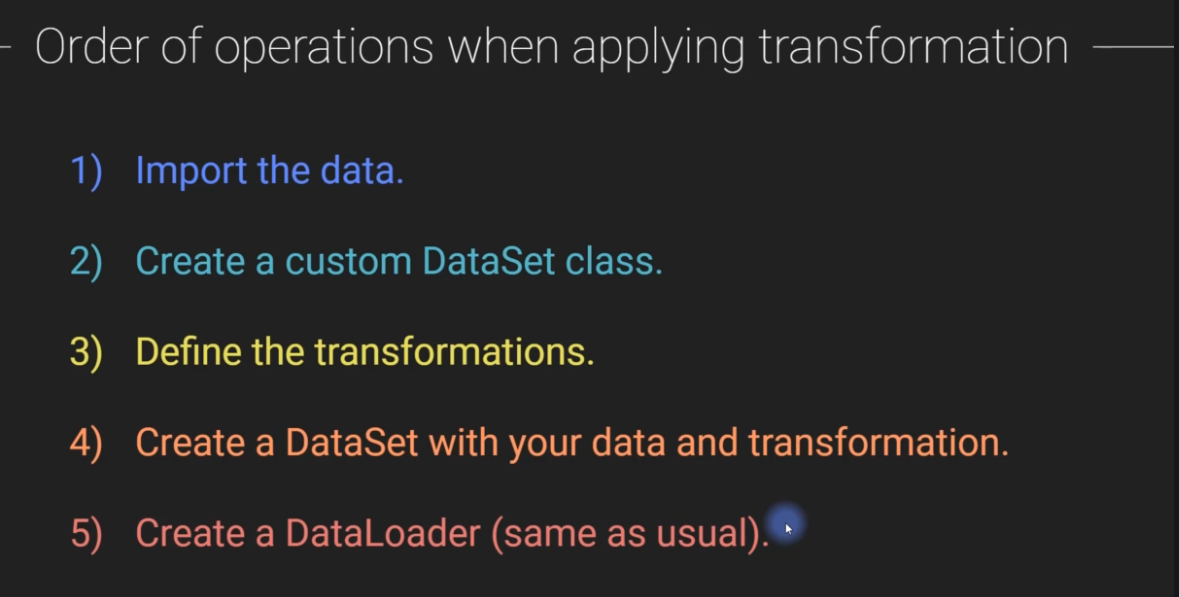

### Torchvision datasets come with added transformations to the class itself.

In [5]:
# Colab's MNIST CSV.
data = pd.read_csv("/content/sample_data/mnist_test.csv")
data.head()

,7,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.658,0.659,0.660,0.661,0.662,0.663,0.664,0.665,0.666,0.667
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# Take 8 images, scale to [0,1], and reshape to PyTorch's (N, C, H, W).
images = data.to_numpy()[:8,1:]
labels = data.to_numpy()[:8,0]

images = images / np.max(images)

images = images.reshape(images.shape[0],1,28,28)

In [7]:
# Tensors: float32 images, int64 labels.
dataT = torch.tensor(images, dtype=torch.float)
labelsT = torch.tensor(labels, dtype=torch.long)

In [8]:
# TensorDataset?? shows its source - which is the template the class below is
# adapted from. Reading the source of a small stdlib class is a good habit.
TensorDataset??

In [9]:
# The custom Dataset. Three methods:
#   __init__     stores the tensors and the transform pipeline,
#   __len__      reports the sample count (DataLoader needs it to build batches),
#   __getitem__  returns ONE (x, y) pair, applying the transform to x only.
#
# Transforming inside __getitem__ is the key design choice: it re-runs on every
# read, so a random augmentation differs every epoch.
# The size guard uses any(...): it fires as soon as ONE tensor has a different
# length. all(...) would only fire when every tensor mismatched, which is not
# the condition you want to catch.
# Creating Custom Dataset , copied the followign from running above code

class CustomDataset(Dataset):

    def __init__(self, tensors, custom_transforms=None) -> None:
        if any(tensors[0].size(0) != tensor.size(0) for tensor in tensors):
            raise AssertionError("Size mismatch between tensors")
        self.tensors = tensors
        self.transforms = custom_transforms

    def __getitem__(self, index):
      # Only Transform if needed.
      if self.transforms:
        X = self.transforms(self.tensors[0][index])
      else :
        X =  self.tensors[0][index]

      Y = self.tensors[1][index]
      return X,Y

    def __len__(self) -> int:
        return self.tensors[0].size(0)

In [10]:
# The augmentation pipeline. ToPILImage -> RandomRotation -> ToTensor: many
# torchvision transforms expect a PIL image, so the round trip is common.
# A small rotation is LABEL-PRESERVING for digits, which a vertical flip is not:
# an upside-down 6 is not a 6, so flipping would teach the model something false.
# Pick augmentations that leave the label true.
Img_transformations = T.Compose([
    T.ToPILImage(),
    T.RandomRotation(15),
    T.ToTensor()
])

In [11]:
# Building the dataset with the transform attached.
custom_data = CustomDataset((dataT,labelsT) , Img_transformations)
type(custom_data)

__main__.CustomDataset

In [12]:
custom_data.tensors[1][1] , custom_data.tensors[0][1].shape

(tensor(1), torch.Size([1, 28, 28]))

In [13]:
# The DataLoader consumes it exactly like a TensorDataset - it only ever calls
# __len__ and __getitem__.
train_loader = DataLoader(custom_data, batch_size=8, shuffle=False)

X,Y = next(iter(train_loader))

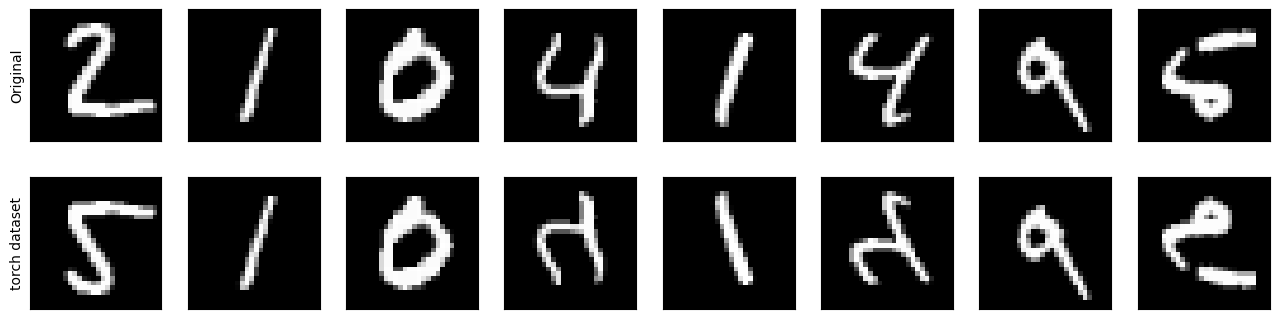

In [14]:
# Original (top) against transformed (bottom): each digit is rotated by its own
# random angle, drawn fresh on every read.
# Run the loader again and the angles change - that is what makes it augmentation
# rather than a fixed preprocessing step.
fig, axs = plt.subplots(2,8, figsize=(16,4))

for i in range(8):
# draw images
  axs[0, i].imshow(dataT[i,0,:,: ].detach(), cmap= 'gray')
  axs[1, i].imshow(X[i,0,:,:].detach(), cmap='gray')
# some niceties
  for row in range(2):
    axs[row, i].set_xticks([])
    axs[row, i].set_yticks([])
# row labels
    axs[0,0].set_ylabel('Original')
    axs[1,0].set_ylabel('torch dataset')

In [15]:
# len() comes straight from __len__.
len(custom_data)

8